In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle
from scipy.optimize import curve_fit
import scipy

In [60]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_sum = pickle.load(f)
    Pk_sum = pickle.load(f)
print("shotnoise", Pk_sum.attrs["shotnoise"])

shotnoise 304.0903879154701


In [61]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.5.pickle", "rb") as f:
    Pk_mean11 = pickle.load(f)
    Pk11 = pickle.load(f)
print("shotnoise", Pk11.attrs["shotnoise"])

shotnoise 105.90268152292435


In [62]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [63]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11.4-11.5.pickle", "rb") as f:
    Pk_mean114 = pickle.load(f)
    Pk114 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [92]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM12-12.5.pickle", "rb") as f:
    Pk_mean12 = pickle.load(f)
    Pk12 = pickle.load(f)
print("shotnoise", Pk12.attrs["shotnoise"])

shotnoise 926.3583221039135


In [64]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [65]:
def kernel_lin(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [66]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [67]:
def W_R(k, R=1):
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [83]:
def scale_dependent_bias_quad(logk, a, c, logk0):
    bias_k = a + c*(logk-logk0)**2 
    return bias_k

In [84]:
def fit_pow_quad(logk, a=1, c=0.01, logk0=-0.5, R=1, kernel_type="lin"):
    bias_k = scale_dependent_bias_quad(logk, a, c, logk0)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        kernel = kernel_NL(10**logk, R=R)
    
    
    result1 = bias_k*Plin(10**logk) - bias_k*kernel - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result1

(0.0, 10.0)

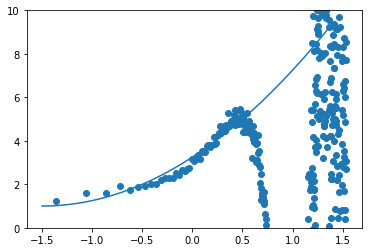

In [85]:
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"])/Plin(Pk11["k"]), label="logM12-12.5")
logks = np.arange(-1.5, 1.5, 0.1)
plt.plot(logks, 1*(logks+1.5)**2 + 1)
plt.ylim(0,10)

(0.0, 10.0)

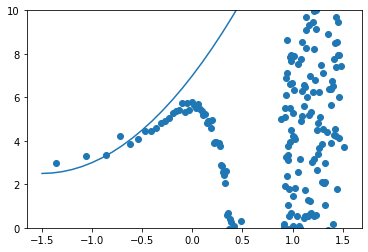

In [161]:
plt.scatter(np.log10(Pk_sum["k"]),(Pk_sum["power"].real-Pk_sum.attrs["shotnoise"])/Plin(Pk11["k"]), label="logM12-12.5")
logks = np.arange(-1.5, 1.5, 0.1)
plt.plot(logks, 2*(logks+1.5)**2 + 2.5)
plt.ylim(0,10)

In [326]:
def optimise_fit(Pk, logM=12, logk_scale=-0.5):
    #mask = (np.log10(Pk["k"]) > logk_scale) 
    mask = (np.log10(Pk["k"]) > -1.5) & (np.log10(Pk["k"]) < 1.3)
    logk1 = np.log10(Pk["k"])[mask]
    pow1 = (Pk["power"].real-Pk.attrs["shotnoise"])[mask]
    
    logk0 = -1.5
    if logM == 12:
        bias1 = 1
        R1 = 0.7
        Rmin = 0.5
        Rmax = 1
        bias_min = 0.9
        bias_max = 1.1
        
        a1 = 2.5
        b1 = 0
        c1 = 2
        d1 = 0
    elif logM == 11:
        R1 = 0.2
        Rmin = 0.1
        Rmax = 0.6
        
        a1 = 1
        b1 = 0
        c1 = 1
        d1 = 0
    elif logM=="all":
        R1 = 0.4
        Rmin = 0.2
        Rmax = 0.8
        
        a1 = 2.5
        b1 = 0
        c1 = 2
        d1 = 0
    
    nmodes = Pk["modes"]
    err = 0.01*pow1/np.sqrt(nmodes[mask])
    mask_err = (np.log10(Pk["k"])[mask] > 1)
    err[mask_err] = 1
    mask_err = (np.log10(Pk["k"])[mask] > 0.5) & (np.log10(Pk["k"])[mask] < 0.7)
    err[mask_err] = 1
    mask_err = (np.log10(Pk["k"])[mask] < 1) & (np.log10(Pk["k"])[mask] > 0.7)
    err[mask_err] = 0.1
    mask_err = (np.log10(Pk["k"])[mask] < 0.5) & (np.log10(Pk["k"])[mask] >-0.5) 
    err[mask_err] = 10*pow1[mask_err]/np.sqrt(nmodes[mask][mask_err])
    
    #weighting_mask = (np.log10(Pk["k"][mask]) > 0.7) & (np.log10(Pk["k"][mask]) < 1.3)
    #weighting = np.ones(len(Pk["k"][mask]))
    #weighting = np.where(weighting_mask,  weighting, 100)
    weighting = Pk["power"].real[mask]
    #p0_1 = [a1, b1, c1, d1,logk0,bias1,R1]
    #bounds1=([-2, -2, -2,-2, -2, bias_min, Rmin], [4, 4, 4,2, 1, bias_max,Rmax])
    #p0_1 = [a1, b1, c1, d1,logk0,R1]
    #bounds1=([0, 0, 0,-0.1, -1.6, Rmin], [4, 0.1, 6,0.1, -1.4, Rmax])
    
    p0_1 = [a1,  c1, logk0,R1]
    bounds1=([0,  0, -4, Rmin], [4,  6, -1, Rmax])
    #pop_fit1, pcov1 = curve_fit(fit_pow_lin, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=err, absolute_sigma=True)

    pop_fit1, pcov1 = curve_fit(fit_pow_quad, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=err, absolute_sigma=True)
    #pop_fit1, pcov1 = curve_fit(fit_pow_quad, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=None)
    
    #pop_fit1, pcov1 = curve_fit(fit_pow_lin_fixed_coef, logk1,kcoef(10**logk1)*pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=None)
    
    
    return pop_fit1

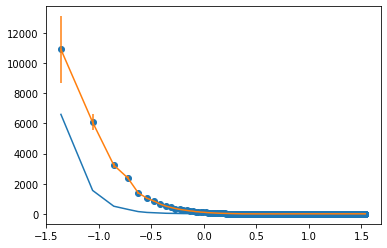

In [293]:
nmodes = Pk_sum["modes"]
plt.plot(np.log10(Pk12["k"]), 3*Pk_sum["power"].real/np.sqrt(nmodes))
#plt.errorbar(np.log10(Pk12["k"]), Pk_sum["power"].real-Pk_sum.attrs["shotnoise"], yerr=10*Pk_sum["power"].real/np.sqrt(nmodes))
plt.errorbar(np.log10(Pk12["k"]), Pk_sum["power"].real-Pk_sum.attrs["shotnoise"], yerr=Pk_sum["power"].real/np.sqrt(nmodes))
plt.scatter(np.log10(Pk12["k"]), Pk_sum["power"].real-Pk_sum.attrs["shotnoise"])
#plt.ylim(-10,1000)

In [327]:
pop_fit12 = optimise_fit(Pk_sum,logM="all")
print(pop_fit12)

[ 3.07552121  0.07396663 -4.          0.61326692]


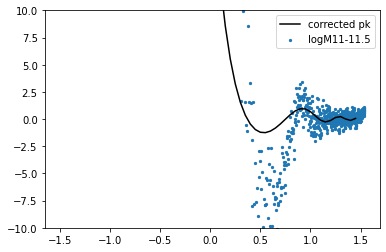

In [204]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, fit_pow_quad(logks, *pop_fit12), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

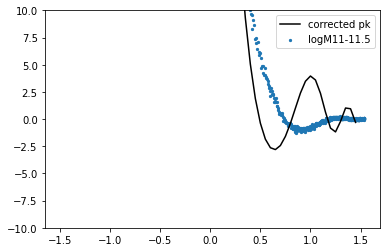

In [174]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, fit_pow_quad(logks, *pop_fit12), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

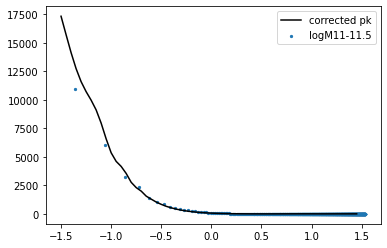

In [329]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk_sum["k"]),Pk_sum["power"].real-Pk_sum.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, fit_pow_quad(logks, *pop_fit12), label="corrected pk", c="k")

#plt.ylim(-5,5)
plt.legend()
